In [ ]:
# # Lexicon discovery: weighted log-odds-ratio

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import (
    CountVectorizer, ENGLISH_STOP_WORDS)

# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #

MODEL_FILTER = None
EPS = 1e-9

# --------------------------------------------------------------------------- #
# Parsing helpers
# --------------------------------------------------------------------------- #

_BID_RE = re.compile(r"Current standing bid:\s*(none|\$?[\d.]+)", re.IGNORECASE)
_ASK_RE = re.compile(r"Current standing ask:\s*(none|\$?[\d.]+)", re.IGNORECASE)
_PRICE_RE = re.compile(r'"price"\s*:\s*(null|-?[\d.]+)')


def iter_records(path):
    """Yield dict records from one file (JSON-lines, or a single JSON array)."""
    with open(path, "r", encoding="utf-8") as f:
        text = f.read().strip()
    if not text:
        return
    if text[0] == "[":
        try:
            for rec in json.loads(text):
                yield rec
            return
        except json.JSONDecodeError:
            pass
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        try:
            yield json.loads(line)
        except json.JSONDecodeError:
            continue


def load_records(sim_files):
    """Load every record from the explicit list of simulation files.

    Tags each record with `_source_file` and `_sim_index` (1-based, in the order
    given) so you can trace any row back to its file. Returns a flat list.
    """
    records = []
    for i, path in enumerate(sim_files, start=1):
        p = Path(path)
        if not p.exists():
            raise FileNotFoundError(f"Simulation file #{i} not found: {p}")
        n_before = len(records)
        for rec in iter_records(p):
            rec["_source_file"] = str(p)
            rec["_sim_index"] = i
            records.append(rec)
        print(f"  sim {i:>2}: {len(records) - n_before:>5} records  ({p.name})")
    print(f"Loaded {len(records)} records from {len(sim_files)} files.")
    return records


def _to_price(token):
    if token is None:
        return None
    token = str(token).strip().lower().lstrip("$")
    if token in ("none", "null", ""):
        return None
    try:
        return float(token)
    except ValueError:
        return None


def parse_standing(rec):
    text = rec.get("user_prompt") or rec.get("prompt") or ""
    bid = _BID_RE.search(text)
    ask = _ASK_RE.search(text)
    return (_to_price(bid.group(1)) if bid else None,
            _to_price(ask.group(1)) if ask else None)


def get_price(rec):
    resp = rec.get("response")
    if isinstance(resp, dict):
        return _to_price(resp.get("price"))
    if isinstance(resp, str):
        try:
            return _to_price(json.loads(resp).get("price"))
        except (json.JSONDecodeError, AttributeError):
            m = _PRICE_RE.search(resp)
            return _to_price(m.group(1)) if m else None
    return None


def classify_move(agent_type, price, bid, ask):
    """'cross', 'increment', or None (no effective order)."""
    if price is None:
        return None
    if agent_type == "buyer":
        if ask is not None and price >= ask - EPS:
            return "cross"
        if bid is None or price > bid + EPS:
            return "increment"
        return None
    if agent_type == "seller":
        if bid is not None and price <= bid + EPS:
            return "cross"
        if ask is None or price < ask - EPS:
            return "increment"
        return None
    return None


def _keep(rec):
    if rec.get("strategy") not in (None, "llm"):
        return False
    if MODEL_FILTER and MODEL_FILTER not in str(rec.get("model_name", "")).lower():
        return False
    return True

# --------------------------------------------------------------------------- #
# Load
# --------------------------------------------------------------------------- #

experiment_id = r"final\results_configs_final\smith1_gemini_large.yaml_combined"

# construct paths
root_path = Path(globals()['_dh'][0]).parent
log_dir = root_path / "results" / experiment_id / "logs"

SIM_FILES = sorted(
    log_dir.glob("*.jsonl"),
    key=lambda p: int(re.search(r"\d+", p.stem).group()),
)

records = load_records(SIM_FILES)

# --------------------------------------------------------------------------- #
# Lexicon discovery
# --------------------------------------------------------------------------- #

# Domain boilerplate that isn't thematic
EXTRA_STOPWORDS = {
    "bid", "bids", "ask", "asks", "price", "prices", "market", "standing",
    "current", "buyer", "seller", "sell", "buy", "trade", "trading", "round",
    "unit", "item", "offer", "order", "ll", "ve", "just", "going", "want",
    "need", "make", "let", "ok", "okay", "situation", "given",
}
STOPWORDS = list(ENGLISH_STOP_WORDS | EXTRA_STOPWORDS)
TOKEN_PATTERN = r"(?u)\b[a-zA-Z]{3,}\b"   # alphabetic, length >= 3 (drops prices)


def phase_corpus(records):
    """(texts, phases) over the analysed population: classified move + thinking."""
    texts, phases = [], []
    for rec in records:
        if not _keep(rec):                       # from lexical_shift.py
            continue
        ph = classify_move(rec.get("agent_type"), get_price(rec),
                           *parse_standing(rec))
        th = (rec.get("thinking") or "").strip()
        if ph is None or not th:
            continue
        texts.append(th)
        phases.append(ph)
    return texts, np.array(phases)


def log_odds_terms(texts, phases, top_n=40, ngram_range=(1, 2),
                   min_df=5, max_df=1.0, prior_scale=1.0):
    """Weighted log-odds-ratio with informative Dirichlet prior (Monroe et al.).

    Pools each phase's token counts, then per term w:
        delta_w = log[(y_cross+a)/(n_cross+a0-y_cross-a)]
                - log[(y_incr +a)/(n_incr +a0-y_incr -a)]
        var_w   = 1/(y_cross+a) + 1/(y_incr+a)
        z_w     = delta_w / sqrt(var_w)
    where the prior a_w = prior_scale * (pooled background count of w) and
    a0 = sum_w a_w. Positive z -> distinctive of the CROSS phase, negative ->
    distinctive of the INCREMENTING phase. prior_scale<1 sharpens (less
    shrinkage); >1 smooths. Returns a DataFrame ranked by |z| within each side.
    """
    phases = np.asarray(phases)
    vec = CountVectorizer(stop_words=STOPWORDS, token_pattern=TOKEN_PATTERN,
                          ngram_range=ngram_range, min_df=min_df, max_df=max_df)
    X = vec.fit_transform(texts)
    vocab = np.array(vec.get_feature_names_out())

    y_incr = np.asarray(X[phases == "increment"].sum(axis=0)).ravel().astype(float)
    y_cross = np.asarray(X[phases == "cross"].sum(axis=0)).ravel().astype(float)
    alpha = (y_incr + y_cross) * prior_scale         # informative prior
    a0 = alpha.sum()
    n_incr, n_cross = y_incr.sum(), y_cross.sum()

    delta = (np.log((y_cross + alpha) / (n_cross + a0 - y_cross - alpha))
             - np.log((y_incr + alpha) / (n_incr + a0 - y_incr - alpha)))
    var = 1.0 / (y_cross + alpha) + 1.0 / (y_incr + alpha)
    z = delta / np.sqrt(var)

    crs = np.argsort(z)[::-1][:top_n]                 # highest z -> cross
    inc = np.argsort(z)[:top_n]                       # lowest z  -> increment
    return pd.DataFrame({
        "increment_term": vocab[inc], "increment_z": np.round(z[inc], 2),
        "cross_term": vocab[crs], "cross_z": np.round(z[crs], 2),
    })


texts, phases = phase_corpus(records)
n_inc = int((phases == "increment").sum())
n_crs = int((phases == "cross").sum())
print(f"{len(texts)} traces  ({n_inc} increment, {n_crs} cross)\n")

# Full 10-sim corpus: min_df=5. Tiny samples: min_df=1.
lo = log_odds_terms(texts, phases, top_n=40)
print("Log-odds-ratio distinctive terms (z-score):")
print(lo.to_string(index=False))

  sim  1:  1500 records  (llm_calls_1.jsonl)
  sim  2:  1500 records  (llm_calls_2.jsonl)
  sim  3:  1500 records  (llm_calls_3.jsonl)
  sim  4:  1500 records  (llm_calls_4.jsonl)
  sim  5:  1500 records  (llm_calls_5.jsonl)
  sim  6:  1500 records  (llm_calls_6.jsonl)
  sim  7:  1500 records  (llm_calls_7.jsonl)
  sim  8:  1500 records  (llm_calls_8.jsonl)
  sim  9:  1500 records  (llm_calls_9.jsonl)
  sim 10:  1500 records  (llm_calls_10.jsonl)
Loaded 15000 records from 10 files.
9505 traces  (9323 increment, 182 cross)

Log-odds-ratio distinctive terms (z-score):
      increment_term  increment_z             cross_term  cross_z
            strategy        -1.33             guaranteed     6.29
                 new        -1.32      guaranteed profit     5.29
         competitive        -1.07             guarantees     4.84
           hopefully        -1.04                   lock     4.69
             improve        -1.03              immediate     4.52
            strictly        -1.


Traces per phase:
   Incremental:  9323
         Cross:   182

Document frequency (% of traces containing the category):
     Strategy & Boundaries | incr  90.0% | cross  52.2%
              Optimization | incr  76.8% | cross  50.0%
                   Urgency | incr  26.8% | cross  96.7%
     Execution & Certainty | incr  25.6% | cross  98.4%


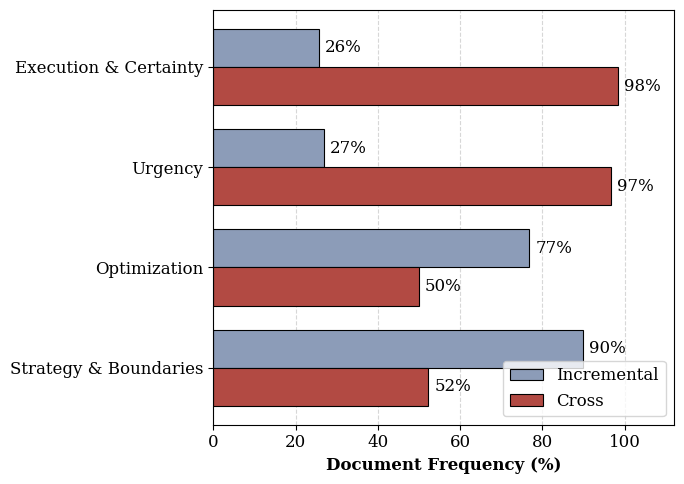

In [4]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --------------------------------------------------------------------------- #
# Configuration
# --------------------------------------------------------------------------- #

# Lexicon. Seed terms are the words italicised in the paper
LEXICON = {
    # increment-distinctive: strategy / competitive / position / room / limit
    "Strategy & Boundaries": [
        r"\bstrateg\w*", r"\bcompetitiv\w*", r"\bposition\w*",
        r"\broom\b", r"\blimit\w*",
    ],
    # increment-distinctive: improve / maximize / increment / increase / best
    "Optimization": [
        r"\bimprov\w*", r"\bmaximi[sz]\w*", r"\bincrement\w*",
        r"\bincreas\w*", r"\bbest\b",
    ],
    # cross-distinctive: immediate(ly) / waiting / overthink
    "Urgency": [
        r"\bimmediat\w*", r"\bwait\w*", r"\boverthink\w*",
    ],
    # cross-distinctive: secure / guarantee / execute / lock / risk
    "Execution & Certainty": [
        r"\bsecur\w*", r"\bguarant\w*", r"\bexecut\w*",
        r"\block\w*", r"\brisk\w*",
    ],
}



# Order bottom -> top on the y-axis (Strategy at the bottom, Execution at top).
CATEGORIES = [
    "Strategy & Boundaries", "Optimization", "Urgency", "Execution & Certainty",
]
PHASES = ["increment", "cross"]
PHASE_LABELS = {"increment": "Incremental", "cross": "Cross"}
PHASE_COLORS = {"increment": "#8C9CB8", "cross": "#B24A43"}
BOLD_THRESHOLD = None  # bold value labels at/above this % (None to disable)

_COMPILED = {
    cat: [re.compile(p, flags=re.IGNORECASE) for p in pats]
    for cat, pats in LEXICON.items()
}

# --------------------------------------------------------------------------- #
# Category presence
# --------------------------------------------------------------------------- #

def present_categories(text):
    """Set of categories that appear at least once in the trace."""
    return {cat for cat, pats in _COMPILED.items()
            if any(pat.search(text) for pat in pats)}

# --------------------------------------------------------------------------- #
# Move table (handy for inspection in the notebook)
# --------------------------------------------------------------------------- #

def moves_dataframe(records):
    """One row per analysed move (classified + non-empty thinking), with a
    boolean column per category. This is exactly the population behind the
    figure, so you can sanity-check counts and read individual traces."""
    rows = []
    for rec in records:
        if not _keep(rec):
            continue
        bid, ask = parse_standing(rec)
        price = get_price(rec)
        phase = classify_move(rec.get("agent_type"), price, bid, ask)
        thinking = (rec.get("thinking") or "").strip()
        if phase is None or not thinking:
            continue
        cats = present_categories(thinking)
        rows.append({
            "sim": rec.get("_sim_index"),
            "round": rec.get("round"),
            "iteration": rec.get("iteration"),
            "agent_type": rec.get("agent_type"),
            "price": price, "bid": bid, "ask": ask,
            "phase": phase,
            **{c: (c in cats) for c in CATEGORIES},
            "thinking": thinking,
        })
    return pd.DataFrame(rows)

# --------------------------------------------------------------------------- #
# Aggregation
# --------------------------------------------------------------------------- #

def aggregate(records):
    """Per phase: how many traces contain each category, and total traces."""
    present = {ph: {c: 0 for c in CATEGORIES} for ph in PHASES}
    doc_totals = {ph: 0 for ph in PHASES}
    for rec in records:
        if not _keep(rec):
            continue
        phase = classify_move(rec.get("agent_type"), get_price(rec),
                              *parse_standing(rec))
        if phase is None:
            continue
        thinking = (rec.get("thinking") or "").strip()
        if not thinking:
            continue
        doc_totals[phase] += 1
        for cat in present_categories(thinking):
            present[phase][cat] += 1
    return present, doc_totals


def doc_frequencies(present, doc_totals):
    return {
        ph: {c: (100.0 * present[ph][c] / doc_totals[ph] if doc_totals[ph] else 0.0)
             for c in CATEGORIES}
        for ph in PHASES
    }

# --------------------------------------------------------------------------- #
# Plotting
# --------------------------------------------------------------------------- #

def plot_shift(freq, title="General Thematic Shift (All Agents)"):
    plt.rcParams.update({"font.family": "serif", "font.size": 12})
    fig, ax = plt.subplots(figsize=(7.0, 5.0))
    y = np.arange(len(CATEGORIES))
    height = 0.38
    for ph, off in [("increment", +height / 2), ("cross", -height / 2)]:
        vals = np.array([freq[ph][c] for c in CATEGORIES])
        ax.barh(y + off, vals, height, label=PHASE_LABELS[ph],
                color=PHASE_COLORS[ph], edgecolor="black", linewidth=0.8)
        for yi, v in zip(y + off, vals):
            weight = ("bold" if BOLD_THRESHOLD is not None and v >= BOLD_THRESHOLD
                      else "normal")
            ax.text(v + 1.5, yi, f"{v:.0f}%", va="center", ha="left",
                    fontsize=12, fontweight=weight)
    ax.set_yticks(y)
    ax.set_yticklabels(CATEGORIES)
    ax.set_xlabel("Document Frequency (%)", fontweight="bold")
    ax.set_xlim(0, 112)
    ax.set_xticks(range(0, 101, 20))
    # ax.set_title(title, fontweight="bold", pad=14)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(loc="lower right", frameon=True, fontsize=12)
    fig.tight_layout()
    return fig, ax

# --------------------------------------------------------------------------- #
# Run
# --------------------------------------------------------------------------- #

df = moves_dataframe(records)          # inspect: df, df["phase"].value_counts(), etc.

present, totals = aggregate(records)
freq = doc_frequencies(present, totals)

print("\nTraces per phase:")
for ph in PHASES:
    print(f"  {PHASE_LABELS[ph]:>12}: {totals[ph]:>5}")
print("\nDocument frequency (% of traces containing the category):")
for c in CATEGORIES:
    print(f"  {c:>24} | incr {freq['increment'][c]:5.1f}% | cross {freq['cross'][c]:5.1f}%")

fig, ax = plot_shift(freq)
plt.show()